<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml05_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

머신러닝(Machine Learning) 종류 - 사람의 감독 하에 훈련하는 것인 지 여부
*   지도학습(supervised learning): 레이블(타겟)이 있는 데이터를 학습.
    *   분류(classification): 클래스들을 분류.
    *   회귀(regression): 수치 예측.
*   비지도학습(unsupervised learning): 레이블이 없는 데이터를 학습.
    *   군집화(clustering)
    *   시각화(visualization)
*   준지도학습(semi-supervised learning): 비지도학습 + 전문가 시스템.

목표: fish 데이터셋에서 물고기의 무게(Weight) 예측.

*   농어(Perch)의 무게(Weight)를 길이(Length) 특성만으로 예측.
    *   Weight ~ Length
    *   무게(Weight): 관심 변수. 종속 변수. 레이블(label). 타겟(target).
    *   길이(Length): 독립 변수. 특성(feature).
    *   KNN, Linear Regression(선형 회귀) 모델을 비교.
*   농어의 무게를 다른 4개의 특성(Length, Diagonal, Height, Width)을 사용해서 예측.
    *   Weight ~ Length + Diagonal + Height + Width

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # 표준화 특성 스케일링 변환기
from sklearn.preprocessing import PolynomialFeatures  # 다차항을 추가할 수 있는 변환기
from sklearn.pipeline import Pipeline  # 변환기와 추정기를 연결하는 클래스
from sklearn.neighbors import KNeighborsRegressor  # KNN 회귀 모델(추정기)
from sklearn.linear_model import LinearRegression  # 선형 회귀 모델(추정기)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # 회귀 평가 지표

# Fish 데이터셋 준비

In [2]:
file_path = 'https://bit.ly/fish_csv_data'
# https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv

In [3]:
fish = pd.read_csv(file_path)

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
# 농어(Perch) 데이터만 선택
perch = fish[fish.Species == 'Perch']

In [6]:
perch.head()

,Species,Weight,Length,Diagonal,Height,Width
72,Perch,5.9,8.4,8.8,2.1120,1.4080
73,Perch,32.0,13.7,14.7,3.5280,1.9992
74,Perch,40.0,15.0,16.0,3.8240,2.4320
75,Perch,51.5,16.2,17.2,4.5924,2.6316
76,Perch,70.0,17.4,18.5,4.5880,2.9415


In [7]:
perch.describe()

,Weight,Length,Diagonal,Height,Width
count,56.000000,56.000000,56.000000,56.000000,56.000000
mean,382.239286,27.892857,29.571429,7.861870,4.745723
std,347.617717,9.021668,9.529509,2.878177,1.774626
min,5.900000,8.400000,8.800000,2.112000,1.408000
25%,120.000000,21.825000,23.325000,5.692500,3.525000
50%,207.500000,25.300000,26.750000,6.921800,4.154900
75%,692.500000,36.625000,39.075000,10.846500,6.448125
max,1100.000000,44.000000,46.600000,12.800200,8.142000


농어의 무게를 길이만으로 예측할 수 있을까?

*   특성(features) 배열: Length --> (n_samples, n_features) shape의 2차원 배열
*   타겟(target) 배열: Weight --> (n_samples,) shape의 1차원 배열

In [8]:
# 특성 배열
x = perch[['Length']].values
x.shape

(56, 1)

In [9]:
# 타겟 배열
y = perch.Weight.values
y.shape

(56,)

# 훈련 셋 vs 테스트 셋 분리

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.25,
                                                    random_state=42)

In [11]:
x_train.shape

(42, 1)

In [12]:
x_test.shape

(14, 1)

In [13]:
y_train.shape

(42,)

In [14]:
y_test.shape

(14,)

훈련 셋, 테스트 셋 산점도, Weight ~ Length

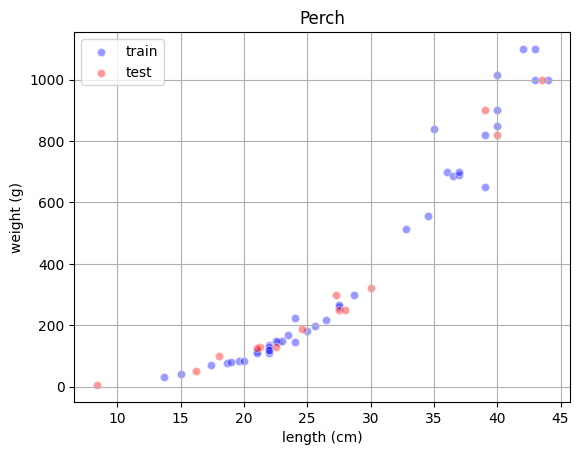

In [15]:
# 훈련 셋 산점도
plt.scatter(x=x_train, y=y_train, alpha=0.4, edgecolor='white', color='blue', label='train')

# 테스트 셋 산점도
plt.scatter(x=x_test, y=y_test, alpha=0.4, edgecolor='white', color='red', label='test')

plt.legend()
plt.grid()
plt.xlabel('length (cm)')
plt.ylabel('weight (g)')
plt.title('Perch')
plt.show()

# KNN 모델 훈련, 평가

KNN(K-Nearest Neighbors) Regressor: k개의 가장 가까운 이웃들의 레이블 평균으로 수치를 예측하는 머신러닝 모델.

In [16]:
knn = KNeighborsRegressor()  # KNN 회귀 모델 생성

In [17]:
knn.fit(X=x_train, y=y_train)  # KNN 회귀 모델 훈련(데이터 학습)

KNeighborsRegressor()

In [18]:
train_pred = knn.predict(X=x_train)  # 훈련 셋 예측값(훈련 셋 농어의 무게 예측값)
print(train_pred)

[  88.6  123.    79.6   70.6  723.   193.   847.   847.  1010.   123.
   95.   123.   174.   248.  1010.   847.   174.   113.   248.   847.
  659.   224.   723.    60.   140.    60.   719.   694.2  248.   167.
  847.   113.   168.   123.  1010.   136.    79.6  719.   123.   193.
  990.   659. ]


In [19]:
print(y_train)  # 훈련 셋 실젯값(훈련 셋 농어의 무게 실젯값)

[  85.  135.   78.   70.  700.  180.  850.  820. 1000.  120.   85.  130.
  225.  260. 1100.  900.  145.  115.  265. 1015.  514.  218.  685.   32.
  145.   40.  690.  840.  300.  170.  650.  110.  150.  110. 1000.  150.
   80.  700.  120.  197. 1100.  556.]


In [20]:
distances, indices = knn.kneighbors(X=x_train)

In [21]:
indices[0]  # 훈련 셋에서 인덱스 0번 물고기와 가장 가까운 이웃들의 인덱스

array([ 0, 10, 36,  2, 17])

In [22]:
y_train[indices[0]]  # 훈련 셋에서 인덱스 0번 물고기와 가장 가까운 이웃들 무게

array([ 85.,  85.,  80.,  78., 115.])

In [23]:
np.mean(y_train[indices[0]])  # 가장 가까운 이웃들의 무게 평균

np.float64(88.6)

In [24]:
test_pred = knn.predict(X=x_test)  # 테스트 셋 예측값(테스트 셋의 농어들의 무게 예측값)
print(test_pred)

[  60.    79.6  248.   122.   136.   847.   311.4  183.4  847.   113.
 1010.    60.   248.   248. ]


In [25]:
print(y_test)  # 테스트 셋 실젯값(테스트 셋의 농어들의 실제 무게)

[   5.9  100.   250.   130.   130.   820.   320.   188.   900.   125.
 1000.    51.5  250.   300. ]


# 회귀 모델의 평가 지표(metrics)

*   MSE(Mean Squared Errors): 오차들의 제곱의 평균.
*   RMSE(Root Mean Squared Errors): MSE의 제곱근(root).
*   MAE(Mean Absolute Errors): 오차들의 절대값의 평균.
*   MSE, RMSE, MAE는 값이 작을 수록 좋은 점수, 값이 클 수록 나쁜 점수.
    *   일반적으로 점수(평가지표)는 값이 클 수록 좋은 점수, 값이 작을 수록 나쁜 점수.
    *   회귀 문제에서도 오차들이 작을 수록 점수가 커지는 평가지표를 개발 -> $R^2$ score(결정 계수)
*   $R^2$ score(coefficient of determinant): - 무한대(infinite) ~ 1 사이의 값을 가질 수 있음.
    *   모든 수치들을 오차없이 정확하게 예측한 경우 결정계수는 최댓값 1.
    *   오차들이 커질 수록 결정 계수는 작아짐.

In [26]:
# 훈련 셋 MSE
mean_squared_error(y_true=y_train, y_pred=train_pred)

3716.5161904761903

In [27]:
# 훈련 셋 RMSE
np.sqrt(mean_squared_error(y_true=y_train, y_pred=train_pred))

np.float64(60.96323638453089)

In [28]:
# 훈련 셋 MAE
mean_absolute_error(y_true=y_train, y_pred=train_pred)

35.76190476190476

In [29]:
# 훈련 셋 R2 score(결정 계수)
r2_score(y_true=y_train, y_pred=train_pred)

0.9698823289099254

In [30]:
# 테스트 셋 MSE
mean_squared_error(y_true=y_test, y_pred=test_pred)
# train MSE > test MSE : 과소적합(under-fitting)

721.7385714285714

In [31]:
# 테스트 셋 MAE
mean_absolute_error(y_true=y_test, y_pred=test_pred)

19.157142857142862

In [32]:
# 테스트 셋 R2 score
r2_score(y_true=y_test, y_pred=test_pred)

0.992809406101064

테스트 셋에서의 평가 지표들이 훈련 셋에서의 평가 지표들보다 더 좋음 -> 과소 적합(under-fitting)

* $ y_i $ : $i$번째 샘플의 실젯값(label)
* $ \hat{y_i} $ : $i$번째 샘플의 예측값
* $ \bar{y} $ : 타겟의 평균값
* $ n $ : 샘플 개수

* MAE(Mean Absolute Errors)
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \lvert y_i - \hat{y_i} \rvert
$$

* MSE(Mean Squared Errors)
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} ( y_i - \hat{y_i} )^2
$$

* RMSE(Root Mean Squared Errors)
$$
RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} ( y_i - \hat{y_i} )^2 }
$$

* $ R^2 $ score(Coefficient of determinant, 결정 계수)
$$
R^2 = 1 - \dfrac{\text{MSE}}{\text{Variance}}
    = 1 - \dfrac{ \sum_{i=1}^{n} (y_i - \hat{y_i})^2 }
                { \sum_{i=1}^{n} (y_i - \bar{y})^2 }
$$
    * 결정 계수는 최댓값이 1이 되도록 만든 평가 지표.
    * 모델이 타겟을 오차없이 정확하게 예측하면, 실제값 - 예측값 = 0 이므로, 결정 계수는 최댓값 1이 됨.
    * 모델이 타겟을 매우 비슷하게 예측하면, 오차가 매우 작으면 분자가 0에 가까운 값이 되므로, 결정 계수는 1보다는 작지만 1에 가까운 값이 됨.
    * 모델이 타겟의 평균으로만 예측하는 정도라면, (분자) = (분모) 이므로, 결정 계수는 0이 됨.
    * 모델이 타겟의 평균 정도도 예측하지 못하면(오차가 매우 크면), (분자) > (분모)일 수 있고, 그런 경우 결정 계수는 음수가 될 수 있음.

In [33]:
knn.score(X=x_test, y=y_test)  #> score = R2 score

0.992809406101064

scikit-learn의 회귀 모델 클래스의 score() 메서드는 $R^2$ score를 리턴.

scikit-learn의 분류 모델 클래스의 score() 메서드는 정확도(accuracy)를 리턴.

# KNN Regressor의 단점

outlier들은 오차가 매우 커질 수 있음.

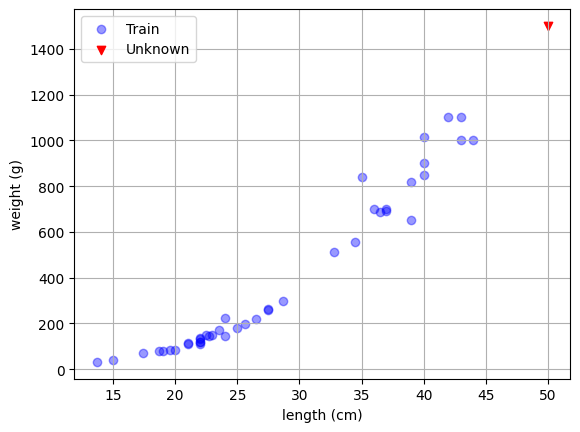

In [34]:
# 훈련 셋 산점도
plt.scatter(x=x_train, y=y_train, color='blue', alpha=0.4, label='Train')

# 가상의 물고기(50cm, 1500g)
plt.scatter(x=50, y=1500, color='red', marker='v', label='Unknown')

plt.legend()
plt.grid()
plt.xlabel('length (cm)')
plt.ylabel('weight (g)')
plt.show()

In [35]:
# 길이 50cm인 물고기의 무게 예측
distances, indices = knn.kneighbors(X=[[50]])  # (주의) (1, 1) shape의 2차원 배열을 사용해야 함!
print('distances:', distances)
print('indices:', indices)

distances: [[ 6.  7.  7.  8. 10.]]
indices: [[34 14  8 40  6]]


In [36]:
y_train[indices[0]]  # 훈련 셋에서 가장 가까운 이웃 5개의 무게들

array([1000., 1100., 1000., 1100.,  850.])

In [37]:
np.mean(y_train[indices[0]])  # KNN 회귀 모델에서 예측값을 찾는 방법

np.float64(1010.0)

In [38]:
knn.predict(X=[[50]])  # 50cm 농어의 무게 예측값.

array([1010.])

머신러닝 종류 - 단순하게 알고 있는 데이터 포인트와 모르는 데이터 포인트를 비교하는 것인 지, 아니면 훈련 셋에서 패턴(수학적인 공식)을 발견해서 예측을 하는 것인 지.

*   사례기반 머신러닝(instance-based Machine Learning)
    *   수학적인 모델을 만들 지 않고, 훈련 셋의 특성들을 사용해서 예측.
    *   (예) KNN, Decision Tree, ...
    *   outlier들이 많은 경우에는 성능이 안 좋아질 수 있음.
*   모델기반 머신러닝(model-based Machine Learning)
    *   훈련 셋의 특성들에서 수학적인 모델(공식)을 만들고, 그 모델로 예측.
    *   (예) Linear Regression, Logistic Regression, SVM, ...


# Linear Regression(선형 회귀)

In [39]:
lin_reg = LinearRegression()  # 선형 회귀 모델 생성

In [40]:
lin_reg.fit(X=x_train, y=y_train)  # 선형 회귀 모델 훈련

LinearRegression()

LinearRegression 모델을 훈련 - 훈련 셋에서 MSE가 최소가 되는 선형 회귀 방정식($y = ax + b$)의 계수(coefficients) a와 절편(intercepts) b를 찾는 과정.

In [41]:
lin_reg.coef_  # x의 계수(y = ax + b 식에서 a)

array([39.01714496])

In [42]:
lin_reg.intercept_  # 절편(y = ax + b 식에서 b)

np.float64(-709.0186449535477)

선형 회귀 모델이 찾은 수학 모델: $y = 39x - 709$

In [43]:
x_train[0]  # 훈련 셋에서 첫번째 농어의 길이

array([19.6])

In [44]:
39 * 19.6 - 709  # 선형 회귀 모델에서 예측한 농어의 무게

55.40000000000009

In [45]:
y_train[0]

np.float64(85.0)

In [46]:
# 선형 회귀 모델에서 훈련 셋의 예측값
train_pred = lin_reg.predict(X=x_train)
print(train_pred)

[  55.71739633  149.35854425   20.60196587  -30.12032259  695.59857374
  266.40997914  851.66715359  812.65000863  968.71858848  149.35854425
   71.32425432  149.35854425  227.39283417  363.95284155  968.71858848
  851.66715359  227.39283417  110.34139928  363.95284155  851.66715359
  570.74370985  324.93569658  715.10714622 -174.48375895  176.67054572
 -123.7614705   734.6157187   656.58142877  410.7734155   207.88426169
  812.65000863  110.34139928  188.37568921  149.35854425 1007.73573345
  168.86711673   32.30710936  734.6157187   149.35854425  289.82026612
  929.70144352  637.07285629]


In [47]:
print(y_train)

[  85.  135.   78.   70.  700.  180.  850.  820. 1000.  120.   85.  130.
  225.  260. 1100.  900.  145.  115.  265. 1015.  514.  218.  685.   32.
  145.   40.  690.  840.  300.  170.  650.  110.  150.  110. 1000.  150.
   80.  700.  120.  197. 1100.  556.]


In [48]:
# 훈련 셋 MSE
mean_squared_error(y_true=y_train, y_pred=train_pred)
#> KNN 모델에서 훈련 셋 MSE보다 훨씬 큼 - 선형 회귀의 성능이 나쁨.

7422.953552609781

In [49]:
# 훈련 셋 결정 계수(r2 score)
lin_reg.score(X=x_train, y=y_train)

0.939846333997604

In [50]:
test_pred = lin_reg.predict(X=x_test)  # 테스트 셋 예측값

In [51]:
# 테스트 셋 MSE
mean_squared_error(y_true=y_test, y_pred=test_pred)

17590.265977889187

In [52]:
# 테스트 셋 결정 계수
lin_reg.score(X=x_test, y=y_test)

0.8247503123313558

훈련 셋의 평가 지표(MSE=7422.9, R2=0.93)가 테스트 셋에서의 평가 지표(MSE=17590.2, R2=0.82)보다 좋음

--> 훈련 셋에서는 잘 맞는 모델, 테스트 셋에서는 잘 맞지 않는 모델.

--> 과대적합(over-fitting)

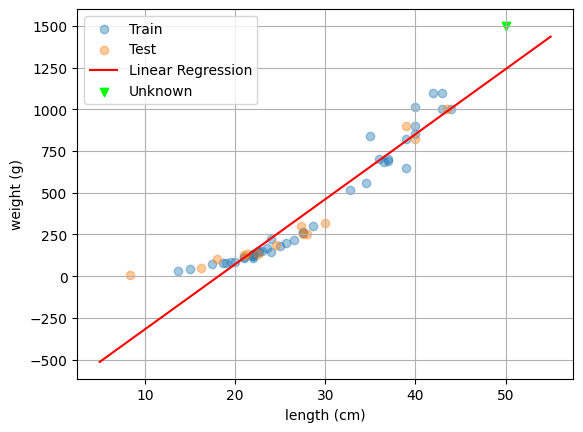

In [53]:
# 훈련 셋 산점도
plt.scatter(x=x_train, y=y_train, label='Train', alpha=0.4)

# 테스트 셋 산점도
plt.scatter(x=x_test, y=y_test, label='Test', alpha=0.4)

# 선형회귀식(y = 39x - 709)을 선 그래프
x_values = np.arange(5, 55, 0.01)
y_values = 39 * x_values - 709
plt.plot(x_values, y_values, 'r-', label='Linear Regression')

# (50cm, 1500g) 가상의 물고기를 점으로 표현
plt.scatter(x=50, y=1500, marker='v', color='Lime', label='Unknown')

plt.legend()
plt.grid()
plt.xlabel('length (cm)')
plt.ylabel('weight (g)')
plt.show()

# 2차항을 포함하는 다항 회귀

*   2개 이상의 특성(독립 변수)들을 사용하는 선형 회귀
    *   $ y = w_0 + w_1 \times x_1 + w_2 \times x_2 + \cdots $
*   2차항을 포함하는 선형 회귀
    *   $ y = ax^2 + bx + c $

In [55]:
# 2차항(물고기 길이의 제곱)을 포함하는 훈련 셋 2차원 배열
x_train_poly = np.c_[x_train ** 2, x_train]

In [56]:
x_train_poly.shape  #> (42, 2) = (n_samples, n_features)

(42, 2)

In [57]:
x_train_poly[:5]

array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ]])

In [58]:
# 2차항을 포함하는 테스트 셋 2차원 배열
x_test_poly = np.c_[x_test ** 2, x_test]

In [59]:
x_test_poly.shape  #> (14, 2)

(14, 2)

In [60]:
x_test_poly[:5]

array([[ 70.56,   8.4 ],
       [324.  ,  18.  ],
       [756.25,  27.5 ],
       [453.69,  21.3 ],
       [506.25,  22.5 ]])

In [61]:
lin_reg = LinearRegression()  # 선형 회귀 모델 생성

In [62]:
lin_reg.fit(X=x_train_poly, y=y_train)
# 길이와 길이의 제곱을 포함하는 훈련 셋으로 선형 회귀 모델을 훈련(학습).
# -> 2차함수 y = ax^2 + bx + c 에서 계수(coefficients) a와 b, 절편(intercepts) c를 찾는 과정.

LinearRegression()

In [63]:
# 훈련이 끝난 모델이 찾은 계수들
lin_reg.coef_

array([  1.01433211, -21.55792498])

In [64]:
# 훈련이 끝난 모델이 찾은 절편
lin_reg.intercept_

np.float64(116.0502107827827)

선형 회귀 모델이 찾은 회귀 방정식:  $ y = 1.01 x^2 - 21.55 x + 116.05 $

In [69]:
1.01 * 19.6 ** 2 - 21.55 * 19.6 + 116.05

81.67160000000005

In [65]:
# 훈련 셋의 예측값들
train_pred = lin_reg.predict(X=x_train_poly)
print(train_pred)

[  83.18070434  132.71260219   67.61880901   48.04150559  654.5393253
  211.05965467  876.66458663  818.09027497 1064.55950693  132.71260219
   90.62455496  132.71260219  182.91530629  290.29593158 1064.55950693
  876.66458663  182.91530629  110.65424646  290.29593158  876.66458663
  500.20932803  257.07992265  680.52990177   11.08663218  149.3605064
   20.90606071  707.0276443   604.07967051  332.83297906  169.60388118
  818.09027497  110.65424646  156.79962213  132.71260219 1131.24847547
  144.50252913   72.62352767  707.0276443   132.71260219  228.92002253
  999.89920261  579.6105922 ]


In [66]:
# 훈련 셋의 실젯값들
print(y_train)

[  85.  135.   78.   70.  700.  180.  850.  820. 1000.  120.   85.  130.
  225.  260. 1100.  900.  145.  115.  265. 1015.  514.  218.  685.   32.
  145.   40.  690.  840.  300.  170.  650.  110.  150.  110. 1000.  150.
   80.  700.  120.  197. 1100.  556.]


In [67]:
# 훈련 셋의 MSE
mean_squared_error(y_true=y_train, y_pred=train_pred)

3617.9917403639624

In [68]:
# 훈련 셋의 R2 score
r2_score(y_true=y_train, y_pred=train_pred)

0.9706807451768623

In [70]:
# 테스트 셋의 예측값
test_pred = lin_reg.predict(X=x_test_poly)
print(test_pred)

[   6.5349146    56.6511646   290.29593158  117.05874344  144.50252913
  876.66458663  382.21135986  199.55847561  818.09027497  110.65424646
 1097.65040817   33.01314491  307.66468513  283.49043666]


In [71]:
print(y_test)  # 테스트 셋의 실젯값

[   5.9  100.   250.   130.   130.   820.   320.   188.   900.   125.
 1000.    51.5  250.   300. ]


In [72]:
# 테스트 셋에서 MSE
mean_squared_error(y_true=y_test, y_pred=test_pred)

2248.9974694392704

In [73]:
# 테스트 셋에서 R2 score
r2_score(y_true=y_test, y_pred=test_pred)

0.9775935108325122

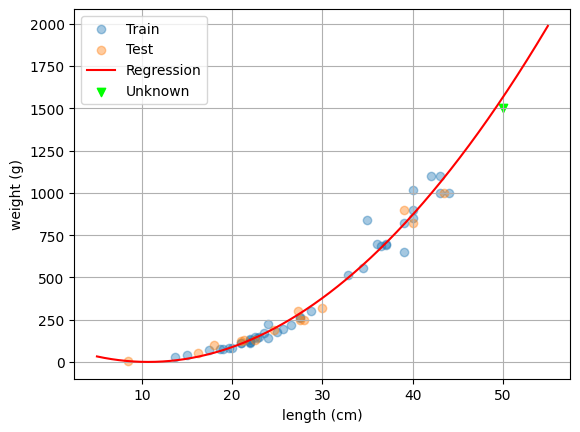

In [78]:
# 훈련 셋 무게 ~ 길이 산점도
plt.scatter(x=x_train, y=y_train, label='Train', alpha=0.4)

# 테스트 셋 무게 ~ 길이 산점도
plt.scatter(x=x_test, y=y_test, label='Test', alpha=0.4)

# 2차항을 포함하는 회귀식(2차 함수) 선그래프
x_values = np.arange(5, 55, 0.001)
y_values = 1.01 * x_values ** 2 - 21.55 * x_values + 116.05
plt.plot(x_values, y_values, 'r-', label='Regression')

# 50cm, 1500g 가상의 물고기 데이터 포인트
plt.scatter(x=50, y=1500, marker='v', color='Lime', label='Unknown')

plt.xlabel('length (cm)')
plt.ylabel('weight (g)')
plt.grid()
plt.legend()
plt.show()

# `numpy.ndarray`를 사용한 행렬 곱(matrix multiplication) 연산

*   `@` 연산자
*   `numpy.matmul()` 함수

## 1차원 배열에서 행렬 곱

In [79]:
a = np.array([1, 2, 3])  # (3,) shape
b = np.array([4, 5, 6])  # (3,) shape

In [80]:
print(a)
print(b)

[1 2 3]
[4 5 6]


In [81]:
a @ b

np.int64(32)

In [82]:
np.matmul(a, b)

np.int64(32)

## 2차원 배열들에서의 행렬 곱

`(i, j) @ (j, k) = (i, k)` shape

In [83]:
a = np.arange(1, 7).reshape((2, 3))  # (2, 3) shape
print(a)

[[1 2 3]
 [4 5 6]]


In [84]:
b = np.ones(shape=(3, 2), dtype=np.int64)
print(b)

[[1 1]
 [1 1]
 [1 1]]


In [85]:
a @ b  # shape: (2, 3) @ (3, 2) = (2, 2)

array([[ 6,  6],
       [15, 15]])

In [86]:
np.matmul(a, b)

array([[ 6,  6],
       [15, 15]])

In [87]:
b @ a  # shape: (3, 2) @ (2, 3) = (3, 3)

array([[5, 7, 9],
       [5, 7, 9],
       [5, 7, 9]])

In [88]:
np.matmul(b, a)

array([[5, 7, 9],
       [5, 7, 9],
       [5, 7, 9]])

행렬 곱셈(matrix multiplication)에서는 교환 법칙이 성립하지 않음.

`a @ b = b @ a`는 성립하지 않음!

In [89]:
print(a)

[[1 2 3]
 [4 5 6]]


In [90]:
b = np.arange(12).reshape((3, 4))
print(b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [91]:
a @ b  #> (2, 3) @ (3, 4) = (2, 4) shape

array([[ 32,  38,  44,  50],
       [ 68,  83,  98, 113]])

In [ ]:
# b @ a  #> (3, 4) @ (2, 3) shape -> matrix multiplication을 할 수 없는 경우.

## 2차원 배열과 1차원 배열 간의 행렬 곱

`(i, j) @ (j,) = (i,)`: 2d array @ 1d array = 1d array

(주의) `(i, j) @ (j, 1) = (i, 1)`: 2d array @ 2d array = 2d array

In [93]:
a = np.arange(1, 7).reshape((2, 3))
print(a)  # (2, 3) shape

[[1 2 3]
 [4 5 6]]


In [94]:
b = np.arange(3)
print(b)  # (3,) shape

[0 1 2]


In [95]:
a @ b  # (2, 3) @ (3,) = (2,)

array([ 8, 17])

In [96]:
c = b.reshape((3, 1))
print(c)

[[0]
 [1]
 [2]]


In [97]:
a @ c  # (2, 3) @ (3, 1) = (2, 1)

array([[ 8],
       [17]])

## 선형회귀 방정식에서 행렬 곱셈 사용

In [98]:
x_train_poly.shape

(42, 2)

In [99]:
x_train_poly[:5]

array([[ 384.16,   19.6 ],
       [ 484.  ,   22.  ],
       [ 349.69,   18.7 ],
       [ 302.76,   17.4 ],
       [1296.  ,   36.  ]])

In [100]:
lin_reg.coef_

array([  1.01433211, -21.55792498])

In [101]:
lin_reg.coef_.shape  # (2,)

(2,)

In [102]:
lin_reg.intercept_  #> scalar

np.float64(116.0502107827827)

In [103]:
x_train_poly @ lin_reg.coef_ + lin_reg.intercept_
#> (42, 2) @ (2,) + scalar = (42,) + scalar = (42,)

array([  83.18070434,  132.71260219,   67.61880901,   48.04150559,
        654.5393253 ,  211.05965467,  876.66458663,  818.09027497,
       1064.55950693,  132.71260219,   90.62455496,  132.71260219,
        182.91530629,  290.29593158, 1064.55950693,  876.66458663,
        182.91530629,  110.65424646,  290.29593158,  876.66458663,
        500.20932803,  257.07992265,  680.52990177,   11.08663218,
        149.3605064 ,   20.90606071,  707.0276443 ,  604.07967051,
        332.83297906,  169.60388118,  818.09027497,  110.65424646,
        156.79962213,  132.71260219, 1131.24847547,  144.50252913,
         72.62352767,  707.0276443 ,  132.71260219,  228.92002253,
        999.89920261,  579.6105922 ])

In [104]:
train_pred

array([  83.18070434,  132.71260219,   67.61880901,   48.04150559,
        654.5393253 ,  211.05965467,  876.66458663,  818.09027497,
       1064.55950693,  132.71260219,   90.62455496,  132.71260219,
        182.91530629,  290.29593158, 1064.55950693,  876.66458663,
        182.91530629,  110.65424646,  290.29593158,  876.66458663,
        500.20932803,  257.07992265,  680.52990177,   11.08663218,
        149.3605064 ,   20.90606071,  707.0276443 ,  604.07967051,
        332.83297906,  169.60388118,  818.09027497,  110.65424646,
        156.79962213,  132.71260219, 1131.24847547,  144.50252913,
         72.62352767,  707.0276443 ,  132.71260219,  228.92002253,
        999.89920261,  579.6105922 ])

행렬 곱셈 사용한 선형 회귀 방정식

$$
y = X \cdot w + w_0
$$

# Pipeline

변환기(transformer)와 추정기(예측기, estimator)를 연결해 주는 클래스

scikit-learn 패키지의 클래스 종류:

*   변환기(transformer)
    *   `fit, fit_transform, transform` 메서드를 가지고 있음.
    *   주로 데이터 전처리(data preprocessing) 과정에서 사용.
    *   (예) `StandardScaler, MinMaxScaler, PolynomialFeatures, ...`
*   추정기(estimator)
    *   `fit, predict, score` 메서드를 가지고 있음.
    *   ML(분류, 회귀, 군집화, ...) 알고리즘을 구현한 클래스.
    *   (예) `KNeighborsClassifier, KNeighborsRegressor, LinearRegression, ...`
